### Setup

- Load the tuned winner model and metadata.
- Retrieve selected features and calibrated risk thresholds.
- Load train, validation, test, and 2020 stress-test datasets.
- Check for missing values in test features.
- Prepare feature matrices for SHAP analysis.

In [2]:
import json, joblib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

import shap

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TARGET       = "next_day_risk_class"
MODEL_DIR = Path("../data/models")
ENG_DIR      = Path("../data/training/engineered")
XAI_DIR      = Path("../data/xai")
OUT_DIR      = Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)
XAI_DIR.mkdir(parents=True, exist_ok=True)

RISK_LABELS = {0: "LOW", 1: "MODERATE", 2: "HIGH"}
RISK_COLORS = {0: "#2ecc71", 1: "#f39c12", 2: "#e74c3c"}

with open(MODEL_DIR / "tuning_meta.json") as f:
    meta = json.load(f)

FEATURES    = meta["features"]
winner_name = meta["winner_model"]
mod_t       = meta["calibration_mod_thresh"]
high_t      = meta["calibration_high_thresh"]

if winner_name == "CatBoost Tuned":
    from catboost import CatBoostClassifier
    model = CatBoostClassifier()
    model.load_model(str(MODEL_DIR / "winner_tuned.cbm"))
else:  
    model = joblib.load(MODEL_DIR / "winner_tuned.pkl")

print(f"Model: {winner_name}")
print(f"Features: {len(FEATURES)}")
print(f"Thresholds: MODERATE>={mod_t}  HIGH>={high_t}")


def predict_class(proba):
    # Shared decision rule: use NB05's calibrated thresholds when valid,
    # otherwise fall back to the model's default argmax decision.
    proba = np.atleast_2d(proba)
    if mod_t is None or high_t is None:
        return np.argmax(proba, axis=1)
    preds = np.zeros(len(proba), dtype=int)
    for i, p in enumerate(proba):
        if p[2] >= high_t:
            preds[i] = 2
        elif p[1] >= mod_t:
            preds[i] = 1
    return preds


train     = pd.read_parquet(ENG_DIR / "train.parquet")
val       = pd.read_parquet(ENG_DIR / "val.parquet")
test      = pd.read_parquet(ENG_DIR / "test.parquet")
stress_20 = pd.read_parquet(ENG_DIR / "stress_2020.parquet")

# Verify no real NaNs are being silently zeroed
na_counts = test[FEATURES].isna().sum()
na_counts = na_counts[na_counts > 0]
if len(na_counts):
    print(f"WARNING: {len(na_counts)} features have NaNs in test — fillna(0) will distort SHAP for these:")
    print(na_counts)
else:
    print("No NaNs in test[FEATURES] — fillna(0) is a no-op safety net.")

X_train = train[FEATURES].fillna(0)
X_val   = val[FEATURES].fillna(0)
X_test  = test[FEATURES].fillna(0)
y_test  = test[TARGET]

print(f"\nTest set: {X_test.shape}")


Model: RF Tuned
Features: 37
Thresholds: MODERATE>=0.4  HIGH>=0.39
No NaNs in test[FEATURES] — fillna(0) is a no-op safety net.

Test set: (68581, 37)


### Compute SHAP Values

- Create a 1,000-row background sample from the training set.
- Build a 5,000-row test sample with extra representation of `HIGH` risk cases.
- Compute SHAP values using `TreeExplainer` with interventional perturbation.
- Separate SHAP values into `LOW`, `MODERATE`, and `HIGH`.

In [3]:
print("Computing SHAP values on test set sample...")

# Background for interventional perturbation
background = X_train.sample(min(1000, len(X_train)), random_state=RANDOM_STATE)

# HIGH-weighted sample: keep proportional LOW/MODERATE, take ALL available HIGH (capped)
N_TOTAL   = 5000
HIGH_CAP  = 800   

high_idx = test.index[test[TARGET] == 2]
high_n   = min(len(high_idx), HIGH_CAP)
high_idx = pd.Series(high_idx).sample(high_n, random_state=RANDOM_STATE).values

remaining = N_TOTAL - high_n
rest = test[test[TARGET] != 2]
rest_idx = (
    rest.groupby(TARGET, group_keys=False)
    .apply(lambda x: x.sample(
        min(len(x), int(remaining * len(x) / len(rest))),
        random_state=RANDOM_STATE
    ))
    .index
)

sample_idx = pd.Index(high_idx).append(rest_idx)

X_shap    = X_test.loc[sample_idx].reset_index(drop=True)
y_shap    = y_test.loc[sample_idx].reset_index(drop=True)
meta_shap = test.loc[sample_idx, ["date","commune_name","wilaya_name","year"]].reset_index(drop=True)

explainer = shap.TreeExplainer(
    model,
    data=background,
    feature_perturbation="interventional"
)
shap_values = explainer.shap_values(X_shap)
print(f"SHAP values shape: {shap_values.shape}")
assert shap_values.shape == (len(X_shap), len(FEATURES), 3), "Unexpected SHAP output shape — check SHAP version"

print(f"Sample: {len(X_shap)} rows  "
      f"(LOW={sum(y_shap==0)}, MOD={sum(y_shap==1)}, HIGH={sum(y_shap==2)})")

sv_low  = shap_values[:, :, 0]
sv_mod  = shap_values[:, :, 1]
sv_high = shap_values[:, :, 2]

Computing SHAP values on test set sample...


100%|===================| 14996/14997 [96:30<00:00]        

SHAP values shape: (4999, 37, 3)
Sample: 4999 rows  (LOW=3670, MOD=529, HIGH=800)


### Global Feature Importance

- Calculate mean absolute SHAP values for each risk class.
- Measure each feature's average contribution magnitude.
- Rank features by their importance for the `HIGH` risk class.
- Visualize the top 15 features across `LOW`, `MODERATE`, and `HIGH`.
- Save the global importance plot 

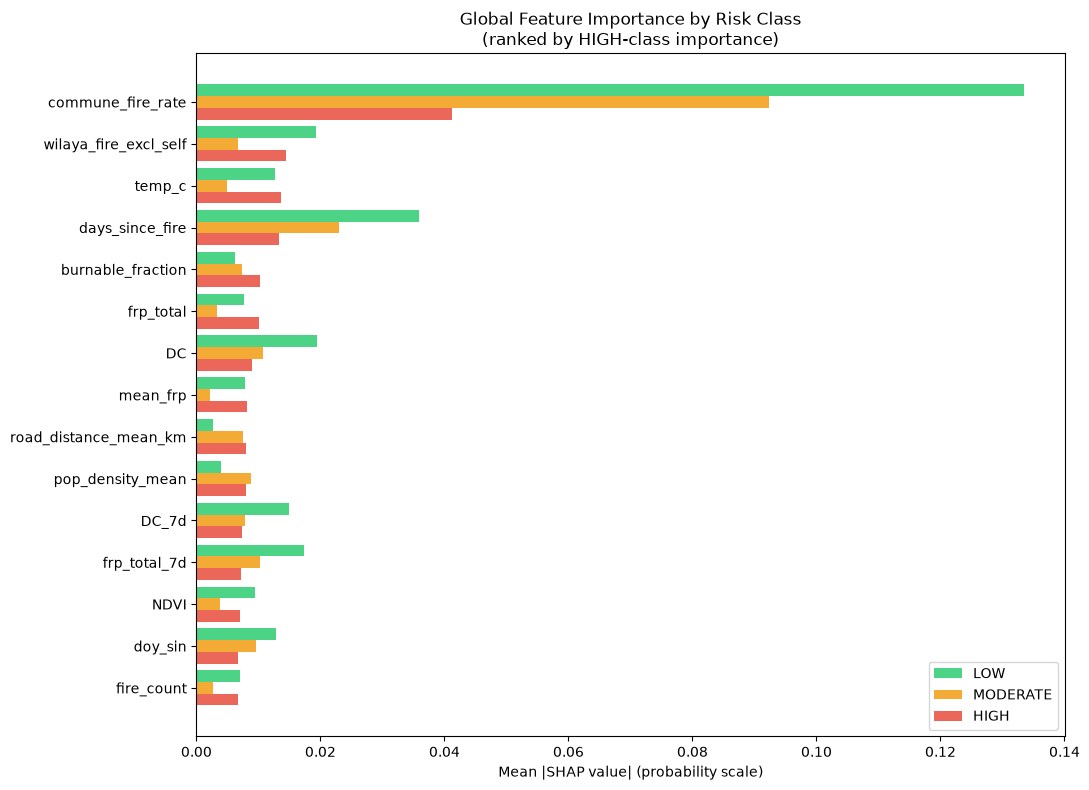

Top 15 features ranked by HIGH-class mean |SHAP|:
              feature      LOW  MODERATE     HIGH  mean_all
    commune_fire_rate 0.133391  0.092273 0.041156  0.088940
wilaya_fire_excl_self 0.019343  0.006650 0.014525  0.013506
               temp_c 0.012731  0.004969 0.013688  0.010462
      days_since_fire 0.035911  0.022944 0.013298  0.024051
    burnable_fraction 0.006251  0.007398 0.010323  0.007991
            frp_total 0.007754  0.003362 0.010102  0.007072
                   DC 0.019506  0.010729 0.009004  0.013080
             mean_frp 0.007854  0.002220 0.008184  0.006086
road_distance_mean_km 0.002731  0.007590 0.007962  0.006094
     pop_density_mean 0.004019  0.008757 0.007923  0.006900
                DC_7d 0.014859  0.007886 0.007278  0.010008
         frp_total_7d 0.017316  0.010259 0.007267  0.011614
                 NDVI 0.009381  0.003875 0.006962  0.006739
              doy_sin 0.012879  0.009689 0.006762  0.009777
           fire_count 0.006952  0.002722 0.006647 

In [6]:
mean_abs_shap = pd.DataFrame({
    "feature":  FEATURES,
    "LOW":      np.abs(sv_low).mean(axis=0),
    "MODERATE": np.abs(sv_mod).mean(axis=0),
    "HIGH":     np.abs(sv_high).mean(axis=0),
})
mean_abs_shap["mean_all"] = mean_abs_shap[["LOW","MODERATE","HIGH"]].mean(axis=1)
# Sort by HIGH specifically — operational focus, and keeps cell 5 consistent
mean_abs_shap = mean_abs_shap.sort_values("HIGH", ascending=False).reset_index(drop=True)

top15 = mean_abs_shap.head(15)

fig, ax = plt.subplots(figsize=(11, 8))
x = np.arange(len(top15))
w = 0.28

ax.barh(x + w, top15["LOW"][::-1].values,      w, label="LOW",      color=RISK_COLORS[0], alpha=0.85)
ax.barh(x,     top15["MODERATE"][::-1].values, w, label="MODERATE", color=RISK_COLORS[1], alpha=0.85)
ax.barh(x - w, top15["HIGH"][::-1].values,     w, label="HIGH",     color=RISK_COLORS[2], alpha=0.85)

ax.set_yticks(x)
ax.set_yticklabels(top15["feature"][::-1], fontsize=10)
ax.set_xlabel("Mean |SHAP value| (probability scale)")
ax.set_title("Global Feature Importance by Risk Class\n(ranked by HIGH-class importance)")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "06_shap_global_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 15 features ranked by HIGH-class mean |SHAP|:")
print(mean_abs_shap.head(15)[["feature","LOW","MODERATE","HIGH","mean_all"]].to_string(index=False))

### SHAP Summary Plots

- Visualize how features influence `HIGH` and `MODERATE` risk predictions.
- Each point represents one sample; color indicates the feature value.
- Positive SHAP values increase the predicted class probability.
- Negative SHAP values decrease it.
- Focus on the direction, magnitude, and distribution of feature effects.

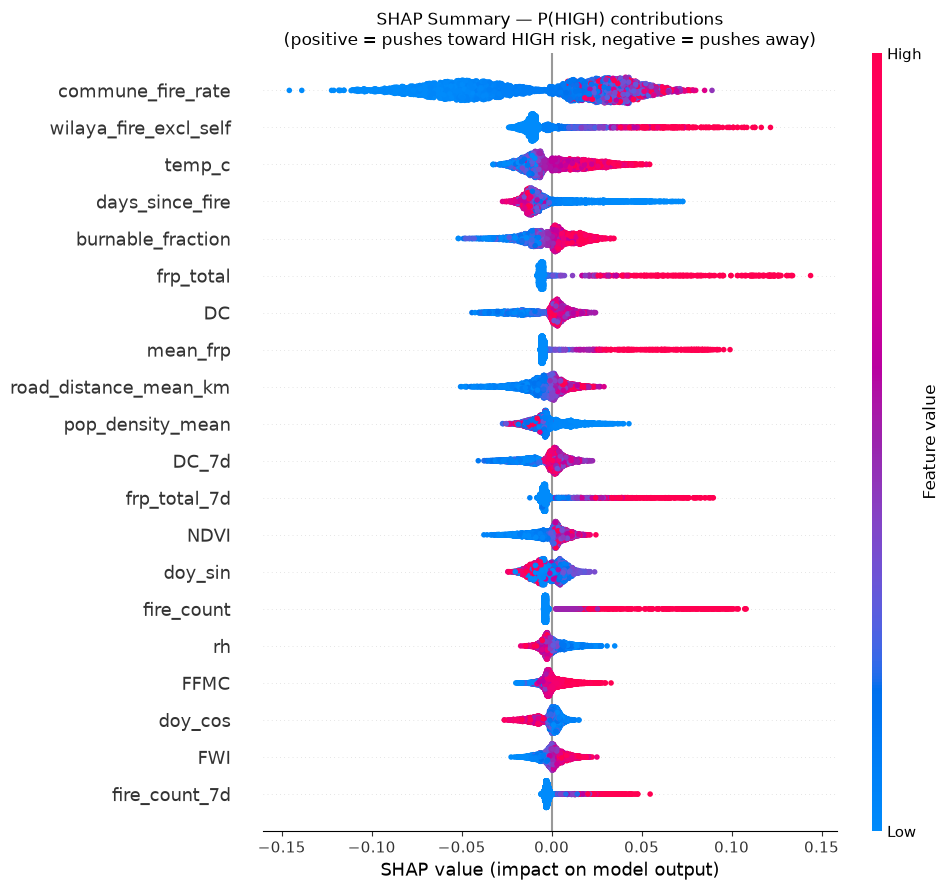

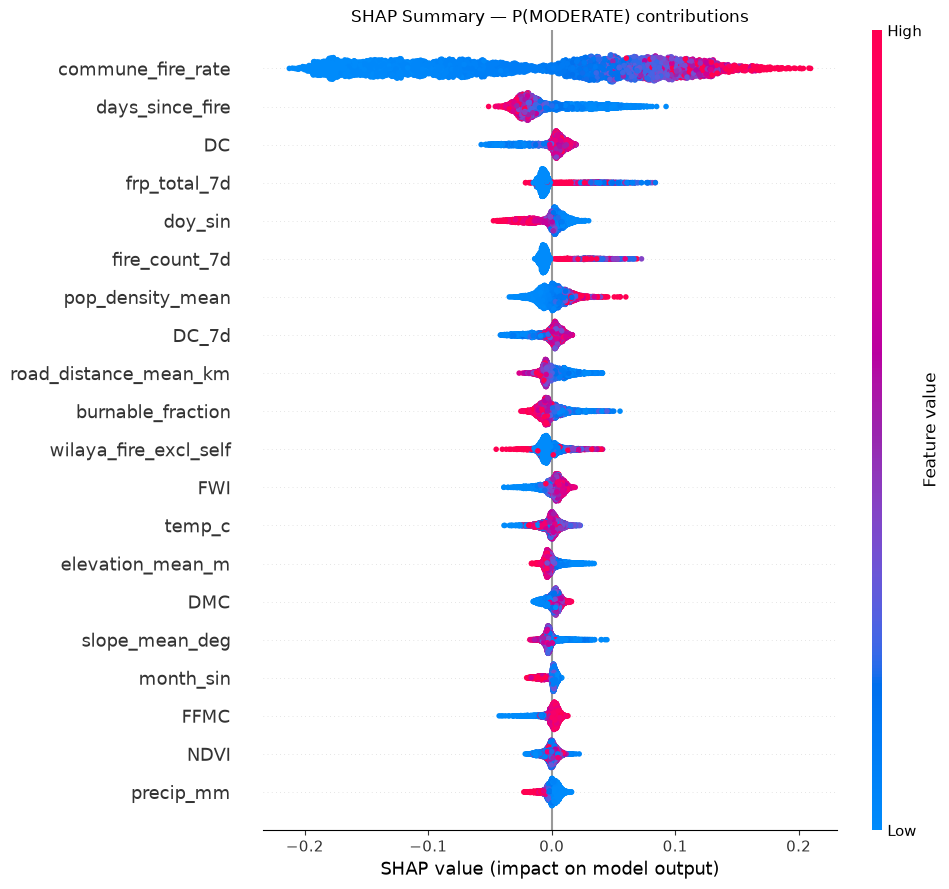

In [7]:
shap.summary_plot(
    sv_high,
    X_shap,
    feature_names=FEATURES,
    plot_type="dot",
    max_display=20,
    show=False,
    plot_size=(10, 9),
    color_bar_label="Feature value"
)
plt.title("SHAP Summary — P(HIGH) contributions\n"
          "(positive = pushes toward HIGH risk, negative = pushes away)")
plt.tight_layout()
plt.savefig(OUT_DIR / "06_shap_summary_high.png", dpi=150, bbox_inches="tight")
plt.show()

# Also generate for MODERATE
shap.summary_plot(
    sv_mod,
    X_shap,
    feature_names=FEATURES,
    plot_type="dot",
    max_display=20,
    show=False,
    plot_size=(10, 9),
)
plt.title("SHAP Summary — P(MODERATE) contributions")
plt.tight_layout()
plt.savefig(OUT_DIR / "06_shap_summary_moderate.png", dpi=150, bbox_inches="tight")
plt.show()

### SHAP Dependence Plots

- Analyze how the top 5 `HIGH`-risk features affect predictions as their values change.
- Reveal nonlinear relationships between feature values and SHAP contributions.
- Use SHAP's automatic interaction coloring to highlight potential feature interactions.
- Focus on the main drivers of `HIGH` risk predictions.

Dependence plots for (ranked by HIGH importance): ['commune_fire_rate', 'wilaya_fire_excl_self', 'temp_c', 'days_since_fire', 'burnable_fraction']


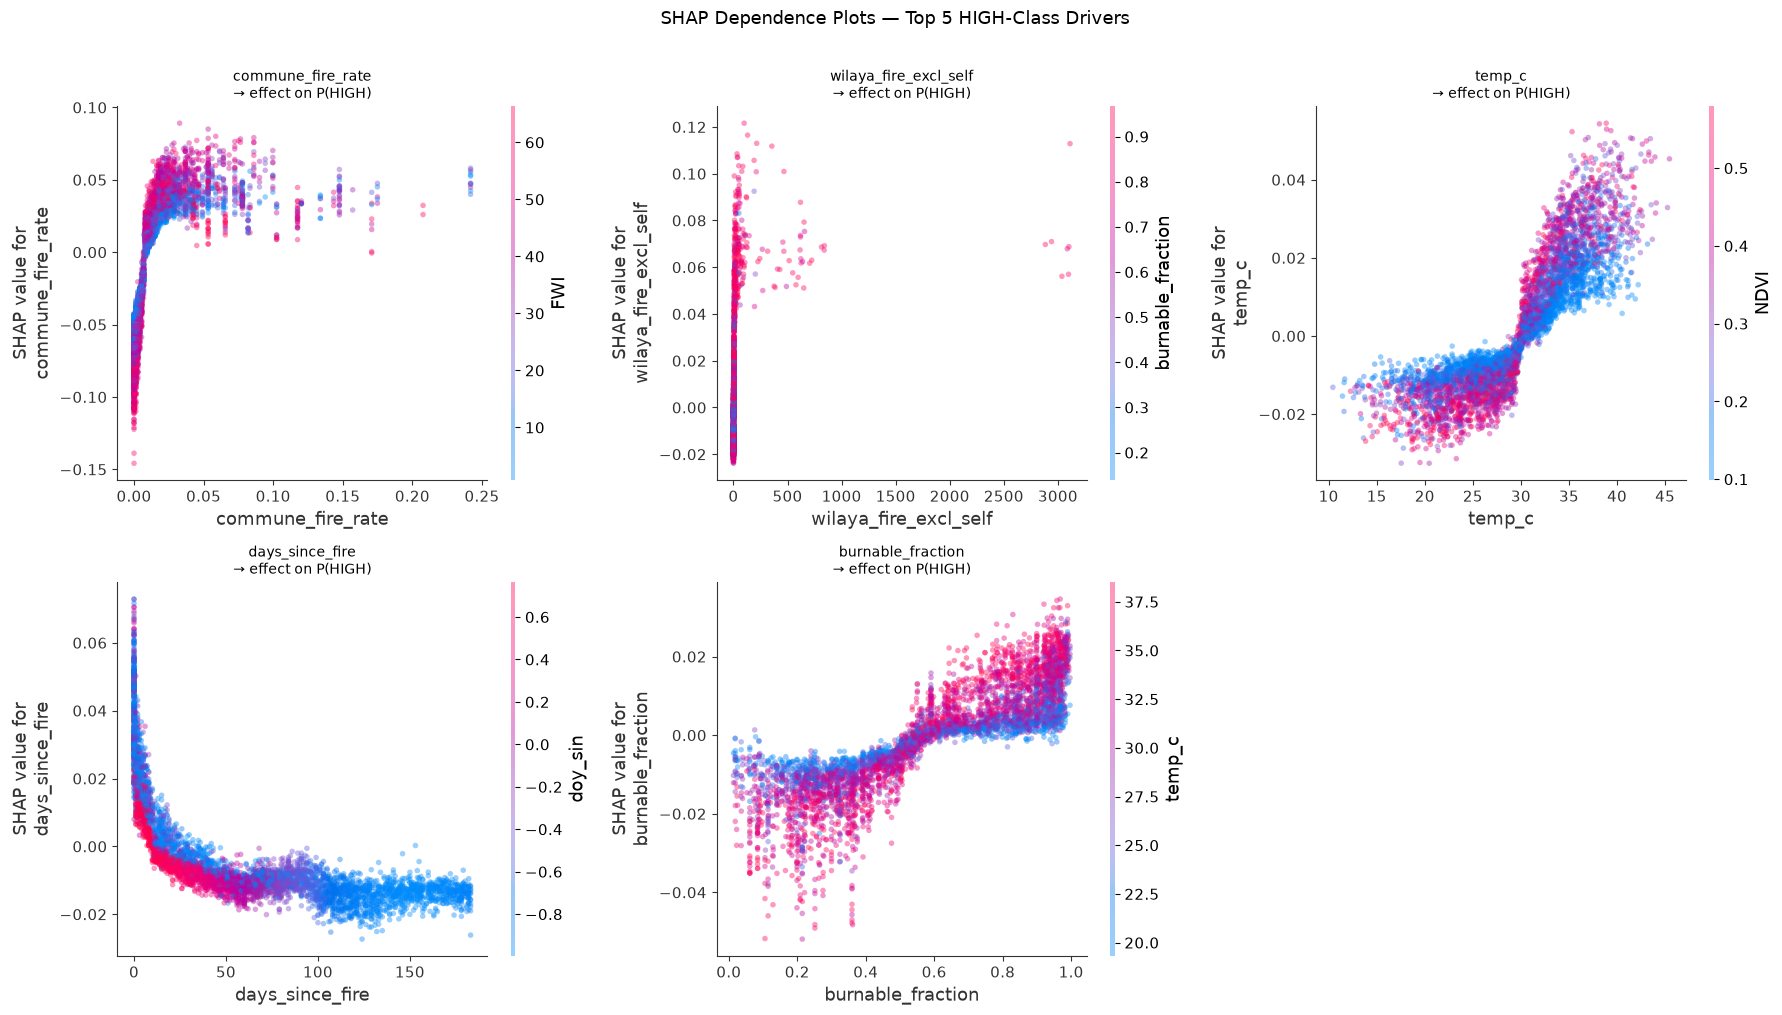

In [8]:
top5 = mean_abs_shap.head(5)["feature"].tolist()  
print(f"Dependence plots for (ranked by HIGH importance): {top5}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(top5):
    feat_idx = FEATURES.index(feat)
    shap.dependence_plot(
        feat_idx,
        sv_high,
        X_shap,
        feature_names=FEATURES,
        ax=axes[i],
        show=False,
        alpha=0.4,
    )
    axes[i].set_title(f"{feat}\n→ effect on P(HIGH)", fontsize=10)

axes[-1].set_visible(False)
plt.suptitle("SHAP Dependence Plots — Top 5 HIGH-Class Drivers",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / "06_shap_dependence_top5.png", dpi=150, bbox_inches="tight")
plt.show()

### Per-Class SHAP Heatmap

- Calculate the mean signed SHAP value for each feature and risk class.
- Positive values indicate a feature pushes predictions toward the class.
- Negative values indicate it pushes predictions away.
- Visualize the 20 strongest class-specific contribution patterns.
- Compare what characterizes `LOW`, `MODERATE`, and `HIGH` risk predictions.

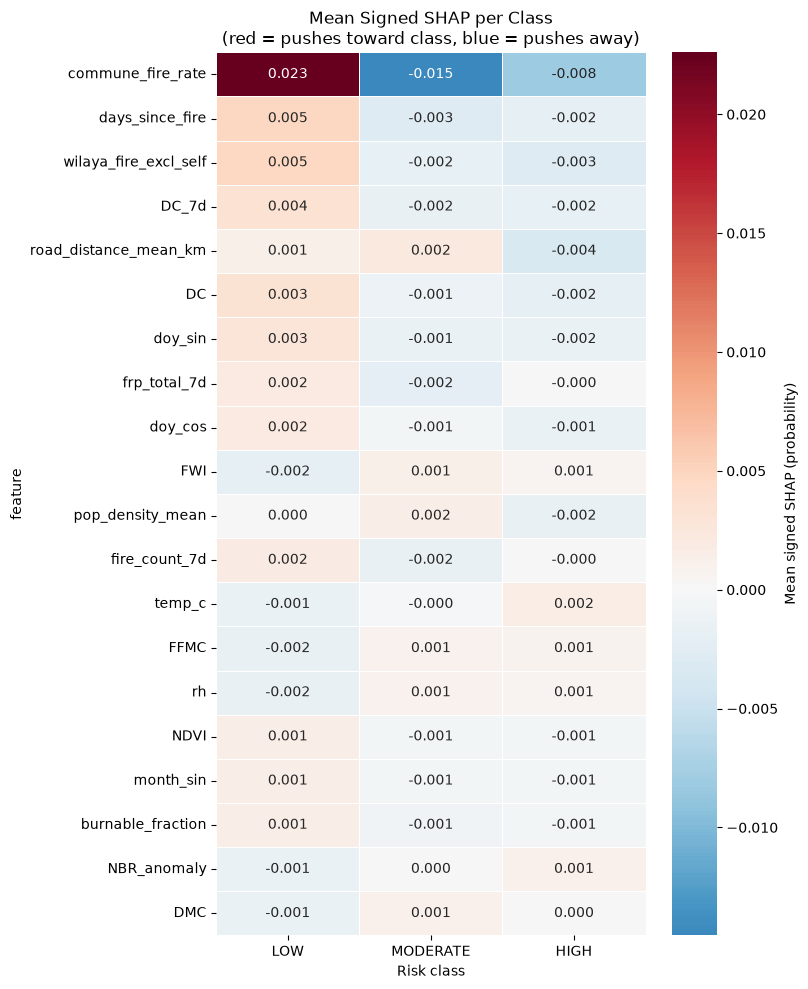

In [9]:
mean_signed = pd.DataFrame({
    "feature":  FEATURES,
    "LOW":      sv_low.mean(axis=0),
    "MODERATE": sv_mod.mean(axis=0),
    "HIGH":     sv_high.mean(axis=0),
}).set_index("feature")

# Keep top 20 by max absolute signed value
top20_signed = mean_signed.loc[
    mean_signed.abs().max(axis=1).nlargest(20).index
]

fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(
    top20_signed,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Mean signed SHAP (probability)"}
)
ax.set_title("Mean Signed SHAP per Class\n"
             "(red = pushes toward class, blue = pushes away)")
ax.set_xlabel("Risk class")
plt.tight_layout()
plt.savefig(OUT_DIR / "06_shap_class_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### Individual Prediction Explanations

- Select representative `HIGH`-risk predictions:
  - **TP:** true HIGH → predicted HIGH.
  - **FP:** true LOW → predicted HIGH.
  - **FN:** true HIGH → predicted LOW.
- Generate SHAP waterfall plots to explain each prediction.
- Show the top feature contributions toward `P(HIGH)`.
- Provide commune, date, true class, predicted class, and probabilities.


Case: True HIGH → predicted HIGH (TP)
Commune: Boukhlifa (Béjaïa)  Date: 2021-08-12 00:00:00
True class: HIGH   Predicted: HIGH
Probabilities: LOW=0.003  MOD=0.137  HIGH=0.860


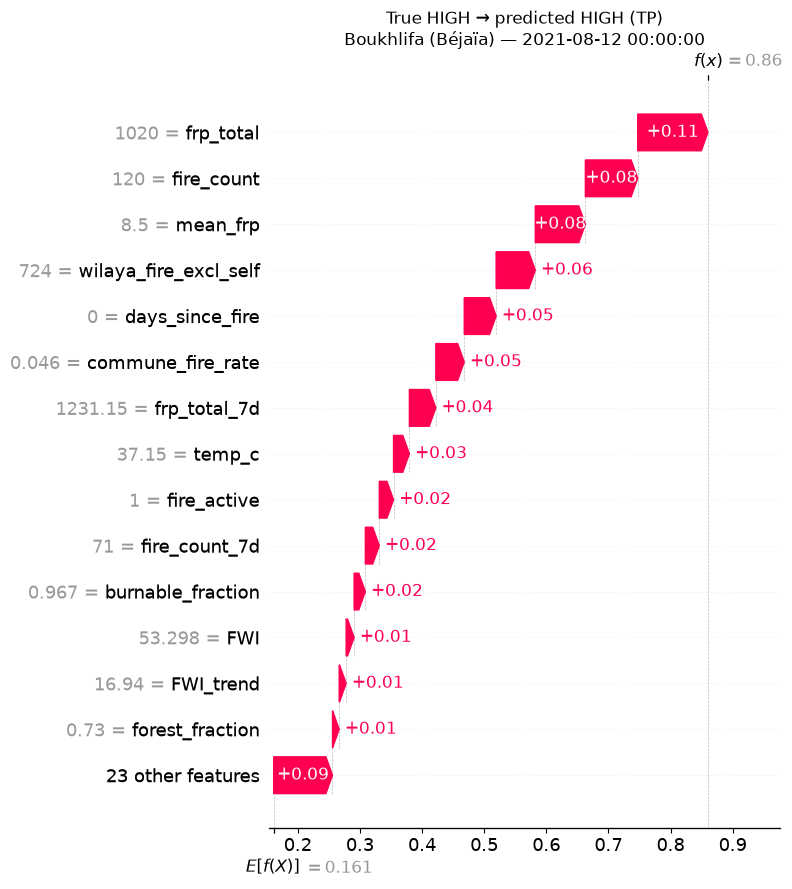


Top 10 feature contributions to P(HIGH):
              feature  shap_high       value
            frp_total   0.112994 1020.000000
           fire_count   0.084263  120.000000
             mean_frp   0.080601    8.500000
wilaya_fire_excl_self   0.063005  724.000000
      days_since_fire   0.051333    0.000000
    commune_fire_rate   0.045761    0.046448
         frp_total_7d   0.042571 1231.150000
               temp_c   0.025511   37.150002
          fire_active   0.022915    1.000000
        fire_count_7d   0.022456   71.000000

Case: True LOW  → predicted HIGH (FP)
Commune: Machroha (Souk Ahras)  Date: 2021-08-28 00:00:00
True class: LOW   Predicted: HIGH
Probabilities: LOW=0.147  MOD=0.424  HIGH=0.429


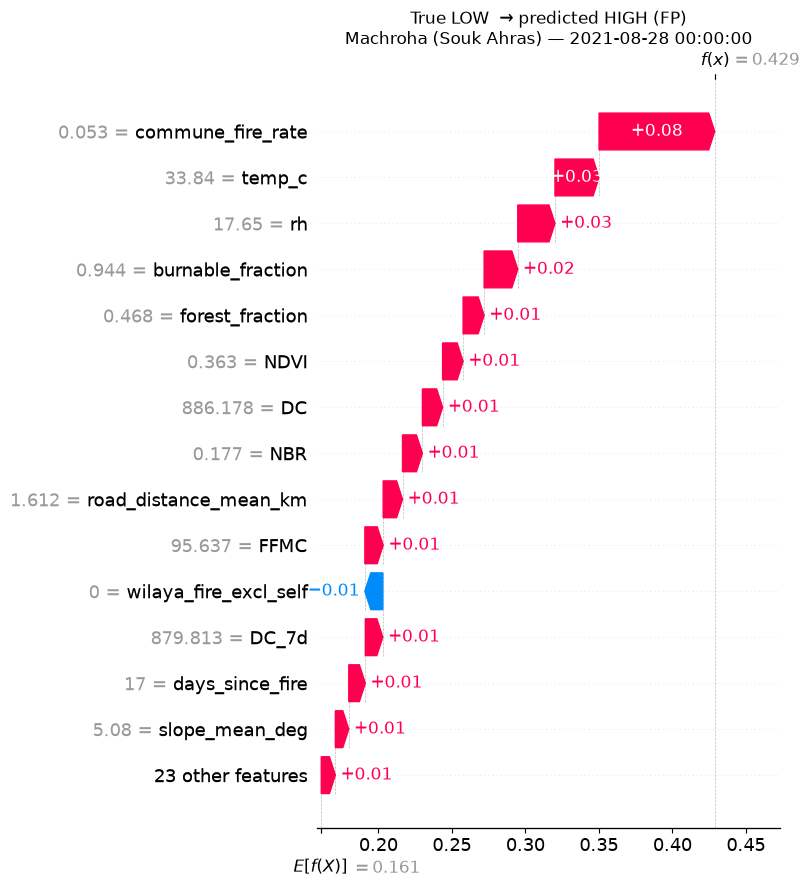


Top 10 feature contributions to P(HIGH):
              feature  shap_high      value
    commune_fire_rate   0.078650   0.053279
               temp_c   0.029988  33.840000
                   rh   0.025317  17.650000
    burnable_fraction   0.022883   0.944200
      forest_fraction   0.014293   0.467500
                 NDVI   0.013938   0.362900
                   DC   0.013744 886.177622
                  NBR   0.013523   0.177500
road_distance_mean_km   0.013160   1.612095
                 FFMC   0.012457  95.637332

Case: True HIGH → predicted LOW  (FN)
Commune: Tamza (Khenchela)  Date: 2021-07-03 00:00:00
True class: HIGH   Predicted: LOW
Probabilities: LOW=0.357  MOD=0.283  HIGH=0.360


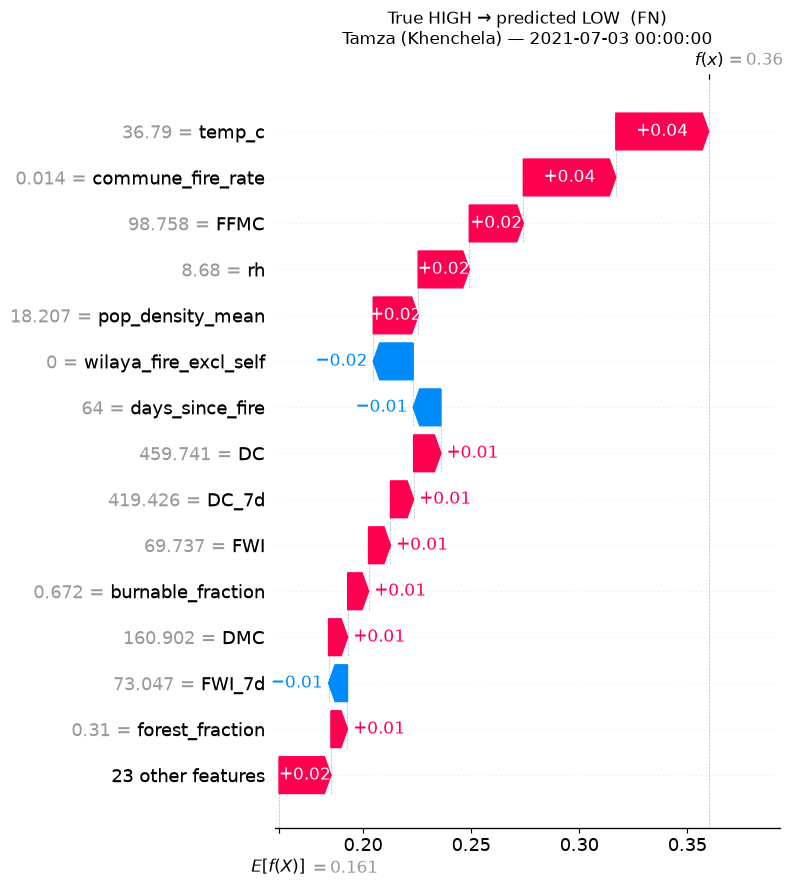


Top 10 feature contributions to P(HIGH):
              feature  shap_high      value
               temp_c   0.042957  36.790001
    commune_fire_rate   0.042775   0.013661
                 FFMC   0.024987  98.758257
                   rh   0.023648   8.680000
     pop_density_mean   0.020785  18.206959
wilaya_fire_excl_self  -0.018489   0.000000
      days_since_fire  -0.012828  64.000000
                   DC   0.012637 459.741352
                DC_7d   0.010702 419.425693
                  FWI   0.010120  69.737392


In [10]:
proba_shap = model.predict_proba(X_shap)
preds_shap = predict_class(proba_shap)

true_high  = np.where((y_shap == 2) & (preds_shap == 2))[0]
false_pos  = np.where((y_shap == 0) & (preds_shap == 2))[0]
false_neg  = np.where((y_shap == 2) & (preds_shap == 0))[0]

# (label, tag) — tag drives the filename, label drives the printed/plot title
cases = {}
if len(true_high): cases["TP"] = ("True HIGH → predicted HIGH (TP)", true_high[0])
if len(false_pos): cases["FP"] = ("True LOW  → predicted HIGH (FP)", false_pos[0])
if len(false_neg): cases["FN"] = ("True HIGH → predicted LOW  (FN)", false_neg[0])

for tag, (case_label, idx) in cases.items():
    print(f"\n{'='*60}")
    print(f"Case: {case_label}")
    commune  = meta_shap.loc[idx, "commune_name"]
    wilaya   = meta_shap.loc[idx, "wilaya_name"]
    date     = meta_shap.loc[idx, "date"]
    true_cls = RISK_LABELS[y_shap[idx]]
    pred_cls = RISK_LABELS[preds_shap[idx]]
    prob     = proba_shap[idx]

    print(f"Commune: {commune} ({wilaya})  Date: {date}")
    print(f"True class: {true_cls}   Predicted: {pred_cls}")
    print(f"Probabilities: LOW={prob[0]:.3f}  MOD={prob[1]:.3f}  HIGH={prob[2]:.3f}")

    shap_ex = shap.Explanation(
        values=sv_high[idx],
        base_values=explainer.expected_value[2],
        data=X_shap.iloc[idx].values,
        feature_names=FEATURES
    )
    shap.waterfall_plot(shap_ex, max_display=15, show=False)
    plt.title(f"{case_label}\n{commune} ({wilaya}) — {date}")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"06_shap_waterfall_{tag}.png", dpi=150, bbox_inches="tight")
    plt.show()

    feat_contrib = pd.DataFrame({
        "feature": FEATURES,
        "shap_high": sv_high[idx],
        "value": X_shap.iloc[idx].values
    }).sort_values("shap_high", key=abs, ascending=False).head(10)
    print("\nTop 10 feature contributions to P(HIGH):")
    print(feat_contrib.to_string(index=False))


### Spatial SHAP Analysis by Wilaya

- Aggregate predicted `P(HIGH)` by wilaya.
- Exclude wilayas with fewer than 15 samples for reliability.
- Identify the 15 wilayas with the highest mean `P(HIGH)`.
- Decompose their predictions using the top 8 `HIGH`-risk features.
- Visualize the main feature contributions across wilayas.

0 wilayas excluded (<15 samples in X_shap)


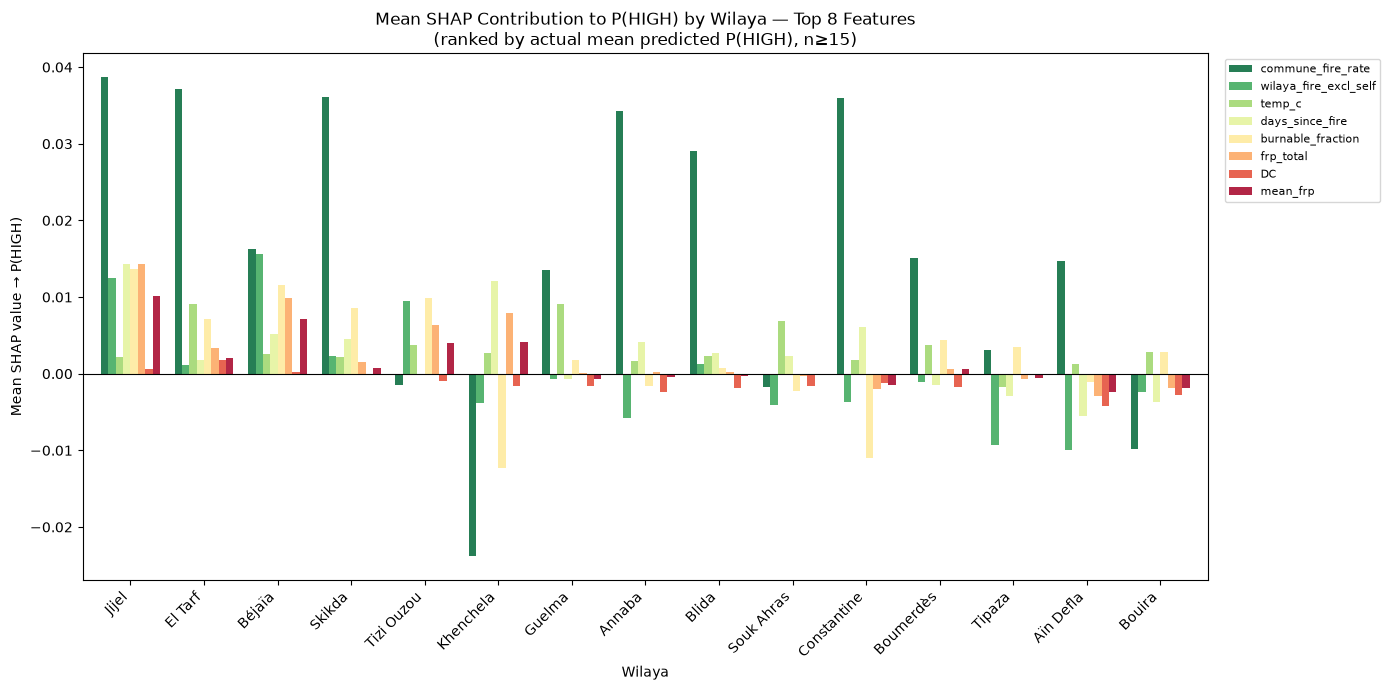

                 mean  count
wilaya_name                 
Jijel        0.311472    226
El Tarf      0.250160    114
Béjaïa       0.244480    295
Skikda       0.217599    206
Tizi Ouzou   0.195313    302
Khenchela    0.192287    111
Guelma       0.189368    131
Annaba       0.184210     55
Blida        0.178793    113
Souk Ahras   0.176024    112
Constantine  0.171264     87
Boumerdès    0.151351    158
Tipaza       0.135467     92
Aïn Defla    0.131148    134
Bouira       0.128136    170


In [11]:
wilaya_proba = pd.DataFrame({
    "wilaya_name": meta_shap["wilaya_name"].values,
    "p_high": proba_shap[:, 2],
})
wilaya_stats = wilaya_proba.groupby("wilaya_name")["p_high"].agg(["mean", "count"]) \
                            .sort_values("mean", ascending=False)

MIN_SAMPLES = 15  # don't trust a wilaya average from a handful of rows
reliable = wilaya_stats[wilaya_stats["count"] >= MIN_SAMPLES]
top_wilayas = reliable.head(15).index
print(f"{len(wilaya_stats) - len(reliable)} wilayas excluded (<{MIN_SAMPLES} samples in X_shap)")

# Feature-level decomposition for those wilayas (diagnostic layer only)
top8_feats = mean_abs_shap.head(8)["feature"].tolist()
top8_idx   = [FEATURES.index(f) for f in top8_feats]

wilaya_shap = pd.DataFrame(sv_high[:, top8_idx], columns=top8_feats)
wilaya_shap["wilaya_name"] = meta_shap["wilaya_name"].values
wilaya_mean = wilaya_shap.groupby("wilaya_name").mean()

fig, ax = plt.subplots(figsize=(14, 7))
wilaya_mean.loc[top_wilayas].plot(
    kind="bar", ax=ax,
    colormap="RdYlGn_r", alpha=0.85, width=0.8
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Mean SHAP Contribution to P(HIGH) by Wilaya — Top 8 Features\n"
             f"(ranked by actual mean predicted P(HIGH), n≥{MIN_SAMPLES})")
ax.set_xlabel("Wilaya")
ax.set_ylabel("Mean SHAP value → P(HIGH)")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUT_DIR / "06_shap_spatial_wilaya.png", dpi=150, bbox_inches="tight")
plt.show()

print(reliable.head(15))

### Temporal SHAP Analysis

- Calculate mean SHAP contributions to `P(HIGH)` for each month.
- Track how the influence of the top 8 features changes throughout the fire season.
- Identify seasonal shifts in the main drivers of `HIGH`-risk predictions.
- Visualize feature contributions from May to October.

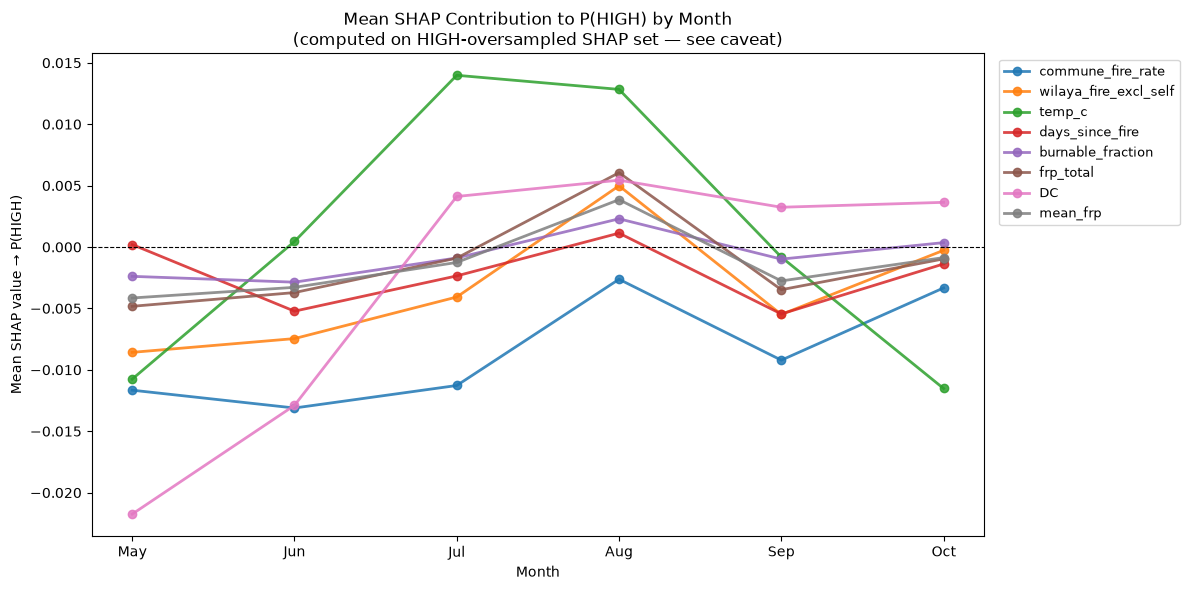

In [12]:
monthly_shap = pd.DataFrame(sv_high[:, top8_idx], columns=top8_feats)
monthly_shap["month"] = pd.to_datetime(meta_shap["date"].values).month
monthly_mean = monthly_shap.groupby("month").mean()

month_names = {5:"May",6:"Jun",7:"Jul",8:"Aug",9:"Sep",10:"Oct"}
monthly_mean.index = monthly_mean.index.map(month_names)

fig, ax = plt.subplots(figsize=(12, 6))
monthly_mean.plot(ax=ax, marker="o", linewidth=2, alpha=0.85)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Mean SHAP Contribution to P(HIGH) by Month\n"
             "(computed on HIGH-oversampled SHAP set — see caveat)")
ax.set_xlabel("Month")
ax.set_ylabel("Mean SHAP value → P(HIGH)")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / "06_shap_temporal.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
FEATURE_LABELS = {
    "commune_fire_rate":     "Historical fire frequency for this commune",
    "frp_total":             "Today's fire radiative power (intensity × count)",
    "mean_frp":              "Average fire intensity today",
    "fire_count":            "Number of fire detections today",
    "frp_total_7d":          "Cumulative fire intensity over past 7 days",
    "fire_count_7d":         "Fire detections over past 7 days",
    "fire_count_3d":         "Fire detections over past 3 days",
    "days_since_fire":       "Days since last fire detection",
    "fire_active":           "Active fire detected today",
    "wilaya_fire_excl_self": "Fires in neighboring communes today",
    "DC":                    "Drought Code (deep soil dryness)",
    "DMC":                   "Duff Moisture Code (organic layer dryness)",
    "FFMC":                  "Fine Fuel Moisture Code (surface fuel dryness)",
    "FWI":                   "Fire Weather Index (overall fire danger)",
    "FWI_7d":                "Average Fire Weather Index over past 7 days",
    "DC_7d":                 "Average Drought Code over past 7 days",
    "DMC_7d":                "Average Duff Moisture Code over past 7 days",
    "FWI_trend":             "Fire danger trend (positive = worsening)",
    "precip_7d":             "Total rainfall over past 7 days",
    "temp_c":                "Air temperature today",
    "rh":                    "Relative humidity today",
    "precip_mm":             "Rainfall today",
    "soil_moisture":         "Soil moisture level",
    "NDVI":                  "Vegetation greenness (fuel availability)",
    "NBR":                   "Vegetation dryness (fuel moisture)",
    "NBR_anomaly":           "Vegetation dryness vs seasonal normal",
    "FFMC_anomaly":          "Surface fuel dryness vs seasonal normal",
    "burnable_fraction":     "Fraction of commune covered by burnable vegetation",
    "forest_fraction":       "Fraction of commune covered by forest",
    "elevation_mean_m":      "Mean elevation of commune",
    "slope_mean_deg":        "Mean terrain slope",
    "pop_density_mean":      "Population density",
    "road_distance_mean_km": "Distance to nearest road",
    "doy_sin":               "Day of year (seasonal position)",
    "doy_cos":               "Day of year (seasonal position)",
    "month_sin":             "Month (seasonal encoding)",
    "month_cos":             "Month (seasonal encoding)",
    "year":                  "Year",
}

FEATURE_UNITS = {
    "temp_c": "°C", "rh": "%", "precip_mm": "mm", "precip_7d": "mm",
    "elevation_mean_m": "m", "slope_mean_deg": "°",
    "pop_density_mean": "people/km²", "road_distance_mean_km": "km",
    "commune_fire_rate": "%", "FWI": "", "DC": "", "DMC": "", "FFMC": "",
    "frp_total": "MW", "mean_frp": "MW", "frp_total_7d": "MW",
}

### SHAP Tipping Points

- Analyze the top 6 `HIGH`-risk features.
- Identify feature values where their SHAP contribution crosses zero.
- Use smoothed trends and the 5th–95th percentile range to reduce noise.
- Detect stable zero-crossings as potential risk tipping points.
- Visualize and report the estimated tipping point for each feature.

commune_fire_rate              tipping point: 0.008 %
wilaya_fire_excl_self          tipping point: 1.000 
temp_c                         tipping point: 29.970 °C
days_since_fire                tipping point: 12.000 
burnable_fraction              tipping point: 0.551 
frp_total                      tipping point: 0.810 MW


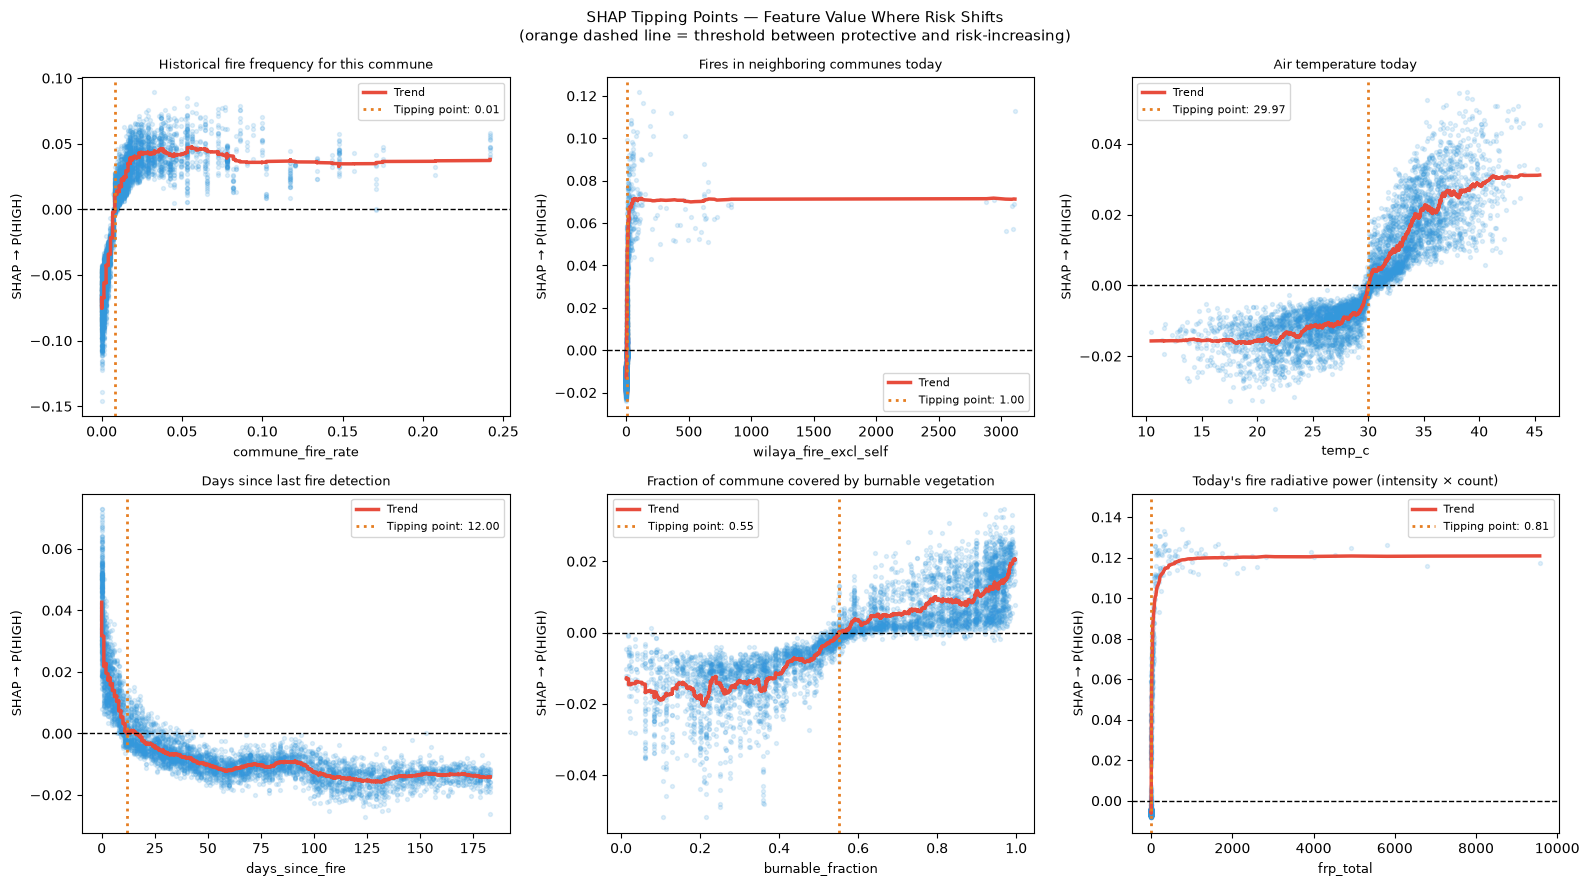

In [14]:
top6 = mean_abs_shap.head(6)["feature"].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(top6):
    feat_idx = FEATURES.index(feat)
    x_vals   = X_shap[feat].values
    y_vals   = sv_high[:, feat_idx]

    sort_idx = np.argsort(x_vals)
    x_s = x_vals[sort_idx]
    y_s = y_vals[sort_idx]

    window = max(1, len(x_s) // 40)
    y_smooth = pd.Series(y_s).rolling(window, center=True, min_periods=1).mean().values

    # Restrict tipping-point search to the 5th-95th percentile range —
    # avoids spurious crossings in sparse tail regions
    lo, hi = np.percentile(x_s, [5, 95])
    core_mask = (x_s >= lo) & (x_s <= hi)
    x_core, y_core = x_s[core_mask], y_smooth[core_mask]

    zero_cross = None
    STABILITY = max(3, window // 4)  # require the sign to hold for a few points after crossing
    for j in range(len(y_core) - STABILITY):
        if y_core[j] * y_core[j+1] < 0:
            after = y_core[j+1 : j+1+STABILITY]
            if np.all(np.sign(after) == np.sign(after[0])):
                zero_cross = x_core[j] + (x_core[j+1]-x_core[j]) * abs(y_core[j]) / (abs(y_core[j])+abs(y_core[j+1]))
                break

    axes[i].scatter(x_s, y_s, alpha=0.15, s=8, color="#3498db")
    axes[i].plot(x_s, y_smooth, color="#e74c3c", linewidth=2.5, label="Trend")
    axes[i].axhline(0, color="black", linewidth=1, linestyle="--")

    if zero_cross is not None:
        axes[i].axvline(zero_cross, color="#e67e22", linewidth=2,
                       linestyle=":", label=f"Tipping point: {zero_cross:.2f}")
        axes[i].legend(fontsize=8)
        unit = FEATURE_UNITS.get(feat, "")
        print(f"{feat:<30} tipping point: {zero_cross:.3f} {unit}")
    else:
        print(f"{feat:<30} no stable tipping point found in 5-95th pct range")

    axes[i].set_xlabel(feat, fontsize=9)
    axes[i].set_ylabel("SHAP → P(HIGH)", fontsize=9)
    axes[i].set_title(FEATURE_LABELS.get(feat, feat), fontsize=9)

plt.suptitle("SHAP Tipping Points — Feature Value Where Risk Shifts\n"
             "(orange dashed line = threshold between protective and risk-increasing)",
             fontsize=11)
plt.tight_layout()
plt.savefig(OUT_DIR / "06_shap_tipping_points.png", dpi=150, bbox_inches="tight")
plt.show()

### Human-Readable Commune Explanation

- Convert model predictions and SHAP values into an interpretable explanation.
- Identify the main factors increasing and reducing `HIGH` risk.
- Format feature values with human-readable labels and units.
- Return both a natural-language summary and structured JSON.
- Save the explanation as an API-ready JSON file.

In [15]:
def format_value(feature, value):
    unit = FEATURE_UNITS.get(feature, "")
    if feature == "commune_fire_rate":
        return f"{value*100:.1f}%"
    elif feature in ["fire_active"]:
        return "Yes" if value > 0 else "No"
    elif feature in ["days_since_fire"]:
        return f"{int(value)} days"
    elif isinstance(value, float):
        return f"{value:.2f}{(' ' + unit) if unit else ''}"
    return f"{value}{(' ' + unit) if unit else ''}"

def explain_commune_human(commune_name, wilaya_name, date, features_today,
                          model, explainer, features):
    """
    Generate a human-readable explanation for a commune's risk prediction.
    Returns both structured JSON and a natural language summary.
    """
    X = pd.DataFrame([features_today])[features].fillna(0)

    proba = model.predict_proba(X)[0]
    pred_class = int(predict_class(proba)[0])  # FIX: shared rule, handles mod_t/high_t == None

    sv   = explainer.shap_values(X)
    sv_h = sv[:, :, 2][0]   # HIGH class SHAP values

    contrib = pd.DataFrame({
        "feature": features,
        "shap":    sv_h,
        "value":   X.iloc[0].values
    }).sort_values("shap", ascending=False)

    top_pos = contrib[contrib["shap"] > 0.005].head(3)
    top_neg = contrib[contrib["shap"] < -0.005].nsmallest(3, "shap")

    risk_label = RISK_LABELS[pred_class]
    prob_high  = proba[2]
    prob_mod   = proba[1]

    summary_lines = [
        f" {commune_name} ({wilaya_name}) — {date}",
        f"Predicted Risk: {risk_label} "
        f"(HIGH: {prob_high:.0%} | MODERATE: {prob_mod:.0%} | LOW: {proba[0]:.0%})",
        "",
        "Main reasons this commune is flagged:"
    ]
    for _, row in top_pos.iterrows():
        label = FEATURE_LABELS.get(row["feature"], row["feature"])
        val   = format_value(row["feature"], row["value"])
        summary_lines.append(f"  ↑ {label}: {val}")

    if len(top_neg):
        summary_lines.append("\nFactors reducing risk:")
        for _, row in top_neg.iterrows():
            label = FEATURE_LABELS.get(row["feature"], row["feature"])
            val   = format_value(row["feature"], row["value"])
            summary_lines.append(f"  ↓ {label}: {val}")

    natural_language = "\n".join(summary_lines)

    result = {
        "commune":     commune_name,
        "wilaya":      wilaya_name,
        "date":        str(date)[:10],
        "risk_class":  risk_label,
        "risk_level":  pred_class,
        "probability": {
            "LOW":      round(float(proba[0]), 3),
            "MODERATE": round(float(proba[1]), 3),
            "HIGH":     round(float(proba[2]), 3),
        },
        "top_risk_drivers": [
            {
                "feature":           row["feature"],
                "label":             FEATURE_LABELS.get(row["feature"], row["feature"]),
                "value":             format_value(row["feature"], row["value"]),
                "raw_value":         round(float(row["value"]), 3),
                "contribution":      round(float(row["shap"]), 4),
                "contribution_pct":  f"+{row['shap']*100:.1f}% toward HIGH"
            }
            for _, row in top_pos.iterrows()
        ],
        "top_protective_factors": [
            {
                "feature":           row["feature"],
                "label":             FEATURE_LABELS.get(row["feature"], row["feature"]),
                "value":             format_value(row["feature"], row["value"]),
                "raw_value":         round(float(row["value"]), 3),
                "contribution":      round(float(row["shap"]), 4),
                # FIX: avoid double-negative phrasing ("-2.3% away from HIGH")
                "contribution_pct":  f"reduces HIGH probability by {abs(row['shap'])*100:.1f}%"
            }
            for _, row in top_neg.iterrows()
        ],
        "natural_language_summary": natural_language,
    }
    return result


# Test on TP example
if len(true_high):
    idx       = true_high[0]
    commune   = meta_shap.loc[idx, "commune_name"]
    wilaya    = meta_shap.loc[idx, "wilaya_name"]
    date      = str(meta_shap.loc[idx, "date"])[:10]
    feats_row = X_shap.iloc[idx]

    explanation = explain_commune_human(
        commune, wilaya, date, feats_row,
        model, explainer, FEATURES
    )

    print(explanation["natural_language_summary"])
    print("\n--- JSON output (for API) ---")
    print(json.dumps(explanation, indent=2))  # FIX: json, not undefined json_lib

    with open(OUT_DIR / "06_example_explanation.json", "w") as f:
        json.dump(explanation, f, indent=2)   # FIX: json, not json_lib
    print("\nSaved → 06_example_explanation.json")

 Boukhlifa (Béjaïa) — 2021-08-12
Predicted Risk: HIGH (HIGH: 86% | MODERATE: 14% | LOW: 0%)

Main reasons this commune is flagged:
  ↑ Today's fire radiative power (intensity × count): 1020.00 MW
  ↑ Number of fire detections today: 120.00
  ↑ Average fire intensity today: 8.50 MW

Factors reducing risk:
  ↓ Distance to nearest road: 0.92 km

--- JSON output (for API) ---
{
  "commune": "Boukhlifa",
  "wilaya": "B\u00e9ja\u00efa",
  "date": "2021-08-12",
  "risk_class": "HIGH",
  "risk_level": 2,
  "probability": {
    "LOW": 0.003,
    "MODERATE": 0.137,
    "HIGH": 0.86
  },
  "top_risk_drivers": [
    {
      "feature": "frp_total",
      "label": "Today's fire radiative power (intensity \u00d7 count)",
      "value": "1020.00 MW",
      "raw_value": 1020.0,
      "contribution": 0.113,
      "contribution_pct": "+11.3% toward HIGH"
    },
    {
      "feature": "fire_count",
      "label": "Number of fire detections today",
      "value": "120.00",
      "raw_value": 120.0,
      "

### False Negative Analysis

- Analyze a true `HIGH`-risk day incorrectly predicted as lower risk.
- Generate a human-readable explanation for the missed prediction.
- Identify features that pushed the prediction away from `HIGH`.
- Highlight potential reasons for the model's missed detection.
- Save the explanation as a structured JSON file.

In [16]:
if len(false_neg):
    idx       = false_neg[0]
    commune   = meta_shap.loc[idx, "commune_name"]
    wilaya    = meta_shap.loc[idx, "wilaya_name"]
    date      = str(meta_shap.loc[idx, "date"])[:10]
    feats_row = X_shap.iloc[idx]

    fn_explanation = explain_commune_human(
        commune, wilaya, date, feats_row,
        model, explainer, FEATURES
    )

    print("FALSE NEGATIVE ANALYSIS — Missed HIGH Risk Day")
    print("=" * 55)
    print(fn_explanation["natural_language_summary"])
    print(f"\nKey insight: why did the model miss this?")

    sv_h_fn = sv_high[idx]
    contrib_fn = pd.DataFrame({
        "feature": FEATURES,
        "shap":    sv_h_fn,
        "value":   feats_row.values
    }).sort_values("shap")

    print("\nFeatures pulling AWAY from HIGH prediction:")
    print(contrib_fn[contrib_fn["shap"] < -0.005].head(5)[
        ["feature","shap","value"]].to_string(index=False))

    with open(OUT_DIR / "06_fn_explanation.json", "w") as f:
        json.dump(fn_explanation, f, indent=2)   

FALSE NEGATIVE ANALYSIS — Missed HIGH Risk Day
 Tamza (Khenchela) — 2021-07-03
Predicted Risk: LOW (HIGH: 36% | MODERATE: 28% | LOW: 36%)

Main reasons this commune is flagged:
  ↑ Air temperature today: 36.79 °C
  ↑ Historical fire frequency for this commune: 1.4%
  ↑ Fine Fuel Moisture Code (surface fuel dryness): 98.76

Factors reducing risk:
  ↓ Fires in neighboring communes today: 0.00
  ↓ Days since last fire detection: 64 days
  ↓ Average Fire Weather Index over past 7 days: 73.05

Key insight: why did the model miss this?

Features pulling AWAY from HIGH prediction:
              feature      shap     value
wilaya_fire_excl_self -0.018489  0.000000
      days_since_fire -0.012828 64.000000
               FWI_7d -0.008751 73.047059
            frp_total -0.005384  0.000000
            FWI_trend -0.005080 -3.309667


### Urgency Scoring

- Combine predicted `HIGH` risk with population, access, and burnable-area exposure.
- Compute an urgency score from 0–100 using predefined weights.
- Assign operational labels: `ROUTINE`, `MONITOR`, `HIGH PRIORITY`, or `CRITICAL`.
- Validate urgency levels against true `HIGH`-risk outcomes in the test set.
- Visualize urgency distributions and save the configuration for the operational pipeline.

Urgency label distribution:
urgency_label
ROUTINE          55587
MONITOR          12210
HIGH PRIORITY      781
CRITICAL             3
Name: count, dtype: int64

True HIGH rate by urgency label:
  CRITICAL       n=      3  true HIGH rate: 66.7%
  HIGH PRIORITY  n=    781  true HIGH rate: 59.3%
  MONITOR        n= 12,210  true HIGH rate: 9.5%
  ROUTINE        n= 55,587  true HIGH rate: 1.5%

Top 20 highest-urgency TRUE HIGH days in test set:
      date     commune_name wilaya_name  urgency_score urgency_label  prob_high  risk_contribution  exposure_contribution  access_contribution  fuel_contribution
2023-07-24          Kerkera      Skikda           72.2      CRITICAL      0.858               42.9                    4.0                 11.1               14.2
2021-08-13 Hammam Ben Salah     El Tarf           70.5      CRITICAL      0.906               45.3                    0.3                 10.7               14.2
2021-08-12 Hammam Ben Salah     El Tarf           69.6 HIGH PRIORITY  

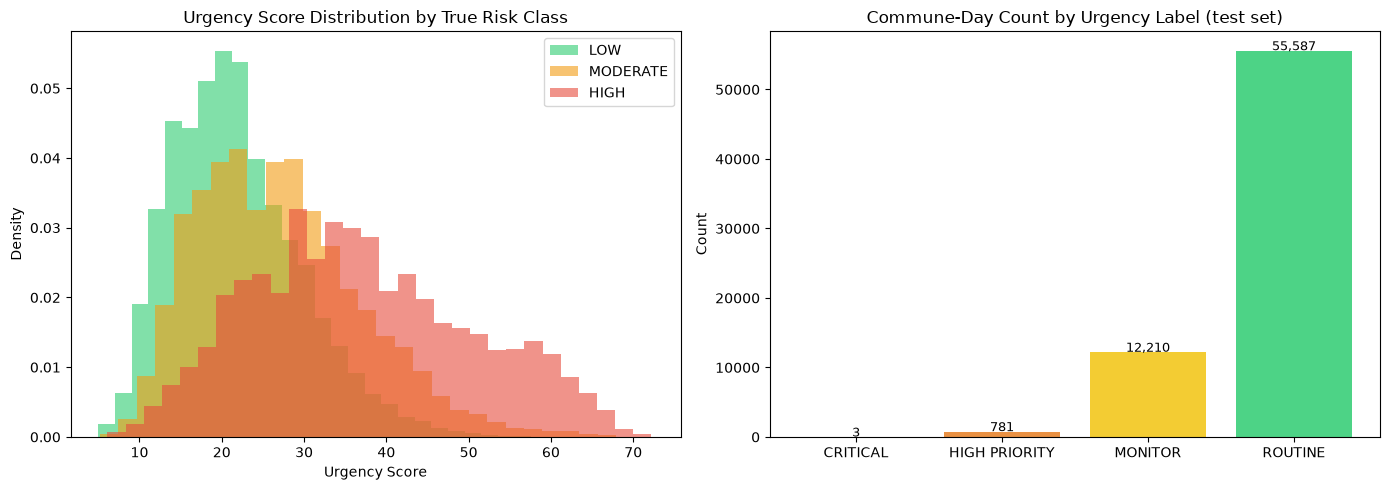


Saved urgency config → 06_urgency_config.json


In [17]:
# Caps derived from TRAIN, not test — test stays held-out for evaluation only
pop_cap  = train["pop_density_mean"].quantile(0.95)
road_cap = train["road_distance_mean_km"].quantile(0.95)

def compute_urgency_score(risk_proba_high, pop_density, road_distance_km,
                          burnable_fraction, pop_cap=pop_cap, road_cap=road_cap):
    pop_score    = min(pop_density / pop_cap, 1.0)
    access_score = min(road_distance_km / road_cap, 1.0)
    fuel_score   = float(burnable_fraction)

    urgency = (
        0.50 * risk_proba_high +
        0.20 * pop_score +
        0.15 * access_score +
        0.15 * fuel_score
    ) * 100

    if urgency >= 70:   label = "CRITICAL"
    elif urgency >= 50: label = "HIGH PRIORITY"
    elif urgency >= 30: label = "MONITOR"
    else:               label = "ROUTINE"

    return urgency, label

# ── Apply to full test set — vectorized ────────────────────────────────────
test_reset = test.reset_index(drop=True)
proba_test = model.predict_proba(X_test)

risk_high    = proba_test[:, 2]
pop_score    = np.minimum(test_reset["pop_density_mean"].values / pop_cap, 1.0)
access_score = np.minimum(test_reset["road_distance_mean_km"].values / road_cap, 1.0)
fuel_score   = test_reset["burnable_fraction"].values.astype(float)

urgency = (0.50*risk_high + 0.20*pop_score + 0.15*access_score + 0.15*fuel_score) * 100

urgency_df = pd.DataFrame({
    "urgency_score":         np.round(urgency, 1),
    "risk_contribution":     np.round(0.50*risk_high*100, 1),
    "exposure_contribution": np.round(0.20*pop_score*100, 1),
    "access_contribution":   np.round(0.15*access_score*100, 1),
    "fuel_contribution":     np.round(0.15*fuel_score*100, 1),
    "commune_name": test_reset["commune_name"].values,
    "wilaya_name":  test_reset["wilaya_name"].values,
    "date":         test_reset["date"].astype(str).str.slice(0, 10).values,
    "prob_high":    np.round(risk_high, 3),
    "true_class":   y_test.values.astype(int),
})
urgency_df["urgency_label"] = pd.cut(
    urgency_df["urgency_score"],
    bins=[-np.inf, 30, 50, 70, np.inf],
    labels=["ROUTINE", "MONITOR", "HIGH PRIORITY", "CRITICAL"]
).astype(str)

# ── Validate: do urgency labels align with true fire outcomes? ────────────
print("Urgency label distribution:")
print(urgency_df["urgency_label"].value_counts())

print("\nTrue HIGH rate by urgency label:")
for label in ["CRITICAL", "HIGH PRIORITY", "MONITOR", "ROUTINE"]:
    mask = urgency_df["urgency_label"] == label
    if mask.sum() == 0: continue
    true_h = (urgency_df.loc[mask, "true_class"] == 2).mean()
    n = mask.sum()
    print(f"  {label:<14} n={n:>7,}  true HIGH rate: {true_h:.1%}")

# ── Top 20 highest urgency days in test set ───────────────────────────────
top20 = (urgency_df[urgency_df["true_class"] == 2]
         .sort_values("urgency_score", ascending=False)
         .head(20)[["date","commune_name","wilaya_name",
                     "urgency_score","urgency_label",
                     "prob_high","risk_contribution",
                     "exposure_contribution","access_contribution",
                     "fuel_contribution"]])

print("\nTop 20 highest-urgency TRUE HIGH days in test set:")
print(top20.to_string(index=False))

print(f"\nNormalization caps used (train, 95th pct):")
print(f"  pop_density cap:   {pop_cap:.0f} people/km²")
print(f"  road_distance cap: {road_cap:.1f} km")

# ── Visualize urgency score distribution ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cls, color, label in [(0,"#2ecc71","LOW"),(1,"#f39c12","MODERATE"),(2,"#e74c3c","HIGH")]:
    mask = urgency_df["true_class"] == cls
    axes[0].hist(urgency_df.loc[mask, "urgency_score"], bins=30,
                 alpha=0.6, color=color, label=label, density=True)
axes[0].set_xlabel("Urgency Score")
axes[0].set_ylabel("Density")
axes[0].set_title("Urgency Score Distribution by True Risk Class")
axes[0].legend()

label_order  = ["CRITICAL","HIGH PRIORITY","MONITOR","ROUTINE"]
label_colors = ["#c0392b","#e67e22","#f1c40f","#2ecc71"]
counts = [urgency_df[urgency_df["urgency_label"]==l].shape[0] for l in label_order]
axes[1].bar(label_order, counts, color=label_colors, alpha=0.85)
axes[1].set_title("Commune-Day Count by Urgency Label (test set)")
axes[1].set_ylabel("Count")
for i, c in enumerate(counts):
    axes[1].text(i, c + 50, f"{c:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / "06_urgency_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Save urgency function and caps for operational pipeline ───────────────
urgency_config = {
    "weights": {
        "risk_proba_high":   0.50,
        "pop_density":       0.20,
        "road_distance":     0.15,
        "burnable_fraction": 0.15,
    },
    "normalization_caps": {
        "pop_density_cap":   round(float(pop_cap), 1),
        "road_distance_cap": round(float(road_cap), 1),
    },
    "thresholds": {
        "CRITICAL":      70,
        "HIGH PRIORITY": 50,
        "MONITOR":       30,
        "ROUTINE":        0,
    },
    "caps_derived_from": "train split (95th percentile)",
    "note": "Weights are a starting point. Validate with Protection Civile domain experts."
}

with open(XAI_DIR / "06_urgency_config.json", "w") as f:
    json.dump(urgency_config, f, indent=2)  
print("\nSaved urgency config → 06_urgency_config.json")

### Equity Analysis

- Evaluate `HIGH`-risk recall separately for each wilaya.
- Compare regional `HIGH` recall and macro F1 performance.
- Flag wilayas with `HIGH` recall below 20%.
- Flag regions with fewer than 5 true `HIGH` samples as insufficient-data.
- Save low-confidence regions for the dashboard's confidence layer.

In [18]:
from sklearn.metrics import recall_score, f1_score  

test_reset = test.reset_index(drop=True)
proba_full = model.predict_proba(X_test)
preds_full = predict_class(proba_full)  # FIX: shared rule, handles mod_t/high_t == None
y_test_arr = y_test.values

equity_rows      = []
insufficient_data = []  

for wilaya in sorted(test_reset["wilaya_name"].unique()):
    mask   = (test_reset["wilaya_name"] == wilaya).values
    y_w    = y_test_arr[mask]
    p_w    = preds_full[mask]
    n_high = int((y_w == 2).sum())

    if n_high < 5:
        insufficient_data.append({"wilaya": wilaya, "n_total": int(mask.sum()), "n_high": n_high})
        continue

    macro_f1    = f1_score(y_w, p_w, labels=[0,1,2], average="macro", zero_division=0)
    high_recall = recall_score(y_w == 2, p_w == 2, zero_division=0)
    low_f1      = f1_score(y_w, p_w, labels=[0,1,2], average=None, zero_division=0)[0]

    equity_rows.append({
        "wilaya":      wilaya,
        "n_total":     int(mask.sum()),
        "n_high":      n_high,
        "macro_f1":    round(macro_f1, 3),
        "high_recall": round(high_recall, 3),
        "low_f1":      round(low_f1, 3),
    })

equity_df = pd.DataFrame(equity_rows).sort_values("high_recall")

print("Per-wilaya HIGH recall (equity analysis):")
print(f"{'Wilaya':<22} {'N-HIGH':>7} {'MacroF1':>9} {'HIGH-Recall':>12}")
print("─" * 55)
for _, row in equity_df.iterrows():
    flag = " Warning" if row["high_recall"] < 0.20 else ""
    print(f"{row['wilaya']:<22} {row['n_high']:>7} "
          f"{row['macro_f1']:>9.3f} {row['high_recall']:>12.3f}{flag}")

underperforming = equity_df[equity_df["high_recall"] < 0.20]["wilaya"].tolist()
print(f"\nWarning  Wilayas with HIGH recall < 20%: {underperforming}")
print(f"   These regions require additional human oversight on the dashboard.")

if insufficient_data:
    print(f"\nWarning  Wilayas with insufficient HIGH samples (<5) for a reliable estimate:")
    for w in insufficient_data:
        print(f"   {w['wilaya']}: n_total={w['n_total']}, n_high={w['n_high']}")
    print("   These should ALSO get a low-confidence badge — absence of data is not")
    print("   evidence of good performance.")

print(f"\nEquity summary:")
print(f"  HIGH recall range:  {equity_df['high_recall'].min():.3f} — "
      f"{equity_df['high_recall'].max():.3f}")
print(f"  HIGH recall std:    {equity_df['high_recall'].std():.3f}")
print(f"  Wilayas analyzed:   {len(equity_df)}  (+ {len(insufficient_data)} insufficient-data)")

low_confidence_wilayas = underperforming + [w["wilaya"] for w in insufficient_data]

equity_config = {
    "low_confidence_wilayas":     low_confidence_wilayas,
    "underperforming_wilayas":    underperforming,
    "insufficient_data_wilayas":  [w["wilaya"] for w in insufficient_data],
    "high_recall_threshold":      0.20,
    "wilaya_performance":         equity_df.to_dict(orient="records"),
    "note": "Wilayas below threshold OR with <5 HIGH test samples are displayed "
            "with a reduced-confidence badge in the dashboard."
}
with open(XAI_DIR / "06_equity_analysis.json", "w") as f:
    json.dump(equity_config, f, indent=2)   
print("\nSaved → 06_equity_analysis.json (used by dashboard confidence layer)")

Per-wilaya HIGH recall (equity analysis):
Wilaya                  N-HIGH   MacroF1  HIGH-Recall
───────────────────────────────────────────────────────
Alger                       14     0.387        0.000 Warning
Aïn Témouchent               7     0.434        0.000 Warning
Tiaret                      20     0.579        0.000 Warning
Tlemcen                     23     0.340        0.000 Warning
Sidi Bel Abbès               8     0.362        0.000 Warning
Relizane                    10     0.415        0.000 Warning
Mostaganem                   9     0.326        0.000 Warning
M'Sila                       9     0.477        0.000 Warning
Mila                        40     0.412        0.050 Warning
Batna                       37     0.572        0.054 Warning
Oran                        65     0.502        0.062 Warning
Bordj Bou Arréridj          20     0.504        0.100 Warning
Constantine                 57     0.403        0.123 Warning
Oum el Bouaghi              16     0.529  

### Save SHAP Artifacts

In [20]:
import pickle

with open(XAI_DIR / "shap_explainer.pkl", "wb") as f:
    pickle.dump(explainer, f)

global_importance = mean_abs_shap[["feature","LOW","MODERATE","HIGH","mean_all"]].to_dict(orient="records")
with open(OUT_DIR / "06_global_shap_importance.json", "w") as f:
    json.dump(global_importance, f, indent=2)   

shap_stats = pd.DataFrame({
    "feature":        FEATURES,
    "mean_shap_low":  sv_low.mean(axis=0).tolist(),
    "mean_shap_mod":  sv_mod.mean(axis=0).tolist(),
    "mean_shap_high": sv_high.mean(axis=0).tolist(),
    "abs_shap_high":  np.abs(sv_high).mean(axis=0).tolist(),
})
shap_stats.to_parquet(OUT_DIR / "06_shap_stats.parquet", index=False)

print("Saved artifacts")

Saved artifacts
